# X-SHOOTER multi-arm PHOENIX classification

This notebook is an advanced example showing how to fit one PHOENIX model to selected windows from the UVB, VIS, and NIR arms of a single X-SHOOTER spectrum.

The fit shares one stellar parameter set across all segments, while each segment keeps its own local continuum correction.


## 1. Imports

We import the Spyctres interfaces needed for reading spectra, building a `SpectrumCollection`, fitting the PHOENIX model, and plotting the result.


In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"pkg_resources is deprecated as an API.*",
    category=UserWarning,
    module=r"pysynphot.*",
)

import numpy as np
import matplotlib.pyplot as plt

from Spyctres.config import load_user_config, get_config_value, resolve_setting
from Spyctres.io import read_spectrum, make_padded_window_segments, SpectrumCollection
from Spyctres.phoenix import PhoenixLibrary
from Spyctres.recipes import (
    attach_balmer_metadata,
    normalize_segments_sidebands,
    make_balmer_core_exclude_mask,
)
from Spyctres.fitting import (
    fit_phoenix_full_spectrum,
    reconstruct_phoenix_legendre_models_for_segments,
)

def print_table(rows, columns=None, float_formats=None):
    if rows is None or len(rows) == 0:
        print("(no rows)")
        return

    if columns is None:
        columns = list(rows[0].keys())
    float_formats = {} if float_formats is None else dict(float_formats)

    def format_value(col, value):
        if isinstance(value, (float, np.floating)):
            fmt = float_formats.get(col, None)
            return format(value, fmt) if fmt is not None else str(float(value))
        return str(value)

    str_rows = []
    for row in rows:
        str_rows.append([format_value(col, row.get(col, "")) for col in columns])

    widths = []
    for j, col in enumerate(columns):
        widths.append(max(len(str(col)), max(len(r[j]) for r in str_rows)))

    header = " | ".join(str(col).ljust(widths[j]) for j, col in enumerate(columns))
    sep = "-+-".join("-" * widths[j] for j in range(len(columns)))

    print(header)
    print(sep)
    for r in str_rows:
        print(" | ".join(r[j].ljust(widths[j]) for j in range(len(columns))))


## 2. Locate the PHOENIX templates and the example data

The PHOENIX path comes from the same config or environment-variable logic used elsewhere in Spyctres.

The notebook can be run either from the repo root or from the `examples/` directory.


In [2]:
config = load_user_config()
phoenix_dir_cfg = get_config_value(config, "paths", "phoenix_dir", default=None)
phoenix_dir = resolve_setting(
    None,
    env_var_name="SPYCTRES_PHOENIX_DIR",
    config_value=phoenix_dir_cfg,
    default=None,
)
if phoenix_dir is None:
    raise RuntimeError(
        "No PHOENIX directory found. Set SPYCTRES_PHOENIX_DIR or configure "
        "~/.config/spyctres/config.toml."
    )

cwd = Path.cwd().resolve()
if (cwd / "examples" / "data").exists():
    data_dir = cwd / "examples" / "data"
elif (cwd / "data").exists():
    data_dir = cwd / "data"
else:
    raise FileNotFoundError(
        "Could not find the example data directory. Run this notebook from the repo root "
        "or from the examples/ directory."
    )

uvb_path = data_dir / "TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_UVB.fits"
vis_path = data_dir / "TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_VIS_TELL_CORR.fits"
nir_path = data_dir / "TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_NIR_TELL_CORR.fits"

for path in [uvb_path, vis_path, nir_path]:
    if not path.exists():
        raise FileNotFoundError(path)

print("PHOENIX dir:", phoenix_dir)
print("Data dir   :", data_dir)
print("Files:")
for path in [uvb_path, vis_path, nir_path]:
    print(" ", path.name)


PHOENIX dir: /home/Tux/ytsapras/Installed_Programs/astroARIADNE/Models_Dir/PHOENIXv2
Data dir   : /home/Tux/ytsapras/Installed_Programs/Spyctres-dev/examples/data
Files:
  TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_UVB.fits
  TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_VIS_TELL_CORR.fits
  TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_NIR_TELL_CORR.fits


## 3. Read the three merged X-SHOOTER spectra

The reader returns one `SpectrumSegment` per arm and stores useful metadata such as the wavelength medium, frame, and nominal resolving power.


In [3]:
uvb = read_spectrum(uvb_path, instrument="xshooter")
vis = read_spectrum(vis_path, instrument="xshooter")
nir = read_spectrum(nir_path, instrument="xshooter")

arms = [uvb, vis, nir]

summary_rows = []
for seg in arms:
    summary_rows.append(
        {
            "name": seg.name,
            "arm": seg.meta.get("arm"),
            "object": seg.meta.get("object"),
            "n_pix": len(seg.wave),
            "wave_min_A": float(np.min(seg.wave)),
            "wave_max_A": float(np.max(seg.wave)),
            "wave_medium": seg.wave_medium,
            "wave_frame": seg.wave_frame,
            "resolution_R": seg.meta.get("resolution_R"),
            "telluric_corrected": seg.meta.get("telluric_corrected"),
        }
    )

print_table(
    summary_rows,
    columns=[
        "name",
        "arm",
        "object",
        "n_pix",
        "wave_min_A",
        "wave_max_A",
        "wave_medium",
        "wave_frame",
        "resolution_R",
        "telluric_corrected",
    ],
    float_formats={
        "wave_min_A": ".1f",
        "wave_max_A": ".1f",
        "resolution_R": ".1f",
    },
)


name                                                   | arm | object    | n_pix | wave_min_A | wave_max_A | wave_medium | wave_frame  | resolution_R | telluric_corrected
-------------------------------------------------------+-----+-----------+-------+------------+------------+-------------+-------------+--------------+-------------------
TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_UVB.fits           | UVB | Gaia21ccu | 12854 | 2989.2     | 5559.8     | air         | topocentric | 5400.0       | False             
TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_VIS_TELL_CORR.fits | VIS | Gaia21ccu | 24318 | 5336.6     | 10200.0    | air         | topocentric | 11000.0      | True              
TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_NIR_TELL_CORR.fits | NIR | Gaia21ccu | 24750 | 9940.2     | 24789.6    | air         | topocentric | 8100.0       | True              


## 4. Quick look at the three arms

This is only a visual check. For plotting only, we trim away the noisiest edges and set the y-range from robust percentiles so the line structure is easier to see.


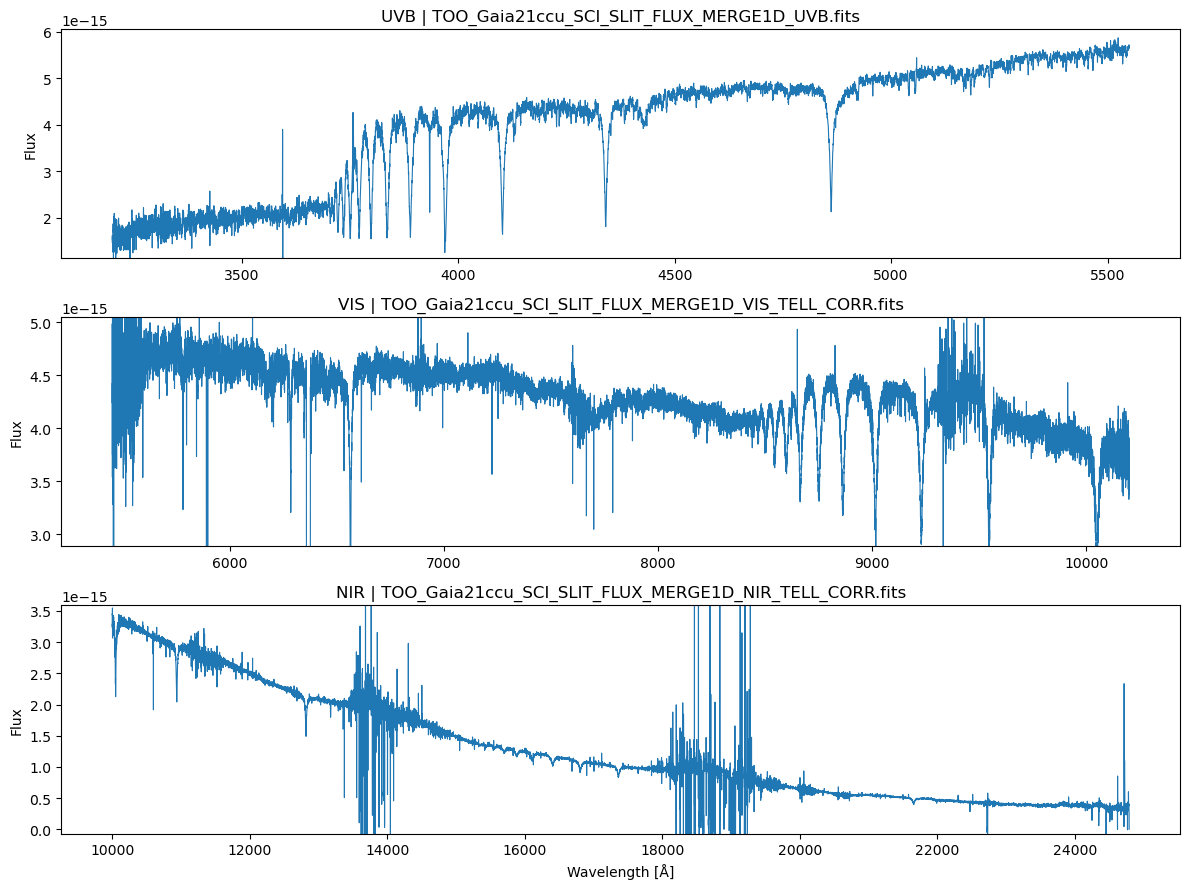

In [4]:
display_ranges = {
    "UVB": (3200.0, 5550.0),
    "VIS": (5450.0, 10250.0),
    "NIR": (10000.0, 24800.0),
}

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

for ax, seg, arm in zip(axes, [uvb, vis, nir], ["UVB", "VIS", "NIR"]):
    lo, hi = display_ranges[arm]

    m = np.isfinite(seg.wave) & np.isfinite(seg.flux)
    m &= (seg.wave >= lo) & (seg.wave <= hi)

    wave = np.asarray(seg.wave[m], dtype=float)
    flux = np.asarray(seg.flux[m], dtype=float)

    ax.plot(wave, flux, lw=0.8)
    ax.set_title(f"{arm} | {seg.name}")
    ax.set_ylabel("Flux")

    if flux.size > 10:
        y1, y2 = np.nanpercentile(flux, [1.0, 99.0])
        pad = 0.1 * (y2 - y1) if y2 > y1 else 1.0
        ax.set_ylim(y1 - pad, y2 + pad)

axes[-1].set_xlabel("Wavelength [Å]")
plt.tight_layout()
plt.show()


## 5. Define the fit windows

We use three Balmer-line windows in the UVB arm, one hydrogen-line window in the VIS arm, and one optional NIR hydrogen-line window.

These are editable starting points. If your data suggest different boundaries, you can change the wavelength ranges directly in the code cell below.


In [5]:
uvb_balmer_windows = [
    ("Hdelta", 3990.0, 4220.0),
    ("Hgamma", 4220.0, 4480.0),
    ("Hbeta", 4700.0, 5020.0),
]

vis_windows = [
    ("Halpha", 6500.0, 6625.0),
]

nir_windows = [
    ("Pabeta", 12775.0, 12855.0),
]

print("UVB windows:", uvb_balmer_windows)
print("VIS windows:", vis_windows)
print("NIR windows:", nir_windows)


UVB windows: [('Hdelta', 3990.0, 4220.0), ('Hgamma', 4220.0, 4480.0), ('Hbeta', 4700.0, 5020.0)]
VIS windows: [('Halpha', 6500.0, 6625.0)]
NIR windows: [('Pabeta', 12775.0, 12855.0)]


## 6. Build the per-window segments

Each segment keeps a padded support region, while its mask marks the inner fit window.

For the broad UVB Balmer lines, we also apply a simple local sideband normalization and exclude a narrow line core. The VIS and NIR windows are left for the fitter's local continuum model.


In [6]:
# Restrict the UVB arm to the wavelength region used in this example.
uvb_clip = uvb.window(wmin=3950.0, wmax=5050.0, name_suffix="fitwin")

uvb_segments = make_padded_window_segments(
    uvb_clip,
    uvb_balmer_windows,
    pad=20.0,
    name_prefix="uvb_balmer",
)

# Give the UVB windows explicit line labels before attaching metadata.
uvb_recipe_labels = ["Hdelta", "Hgamma", "Hbeta"]
for seg_i, label in zip(uvb_segments, uvb_recipe_labels):
    seg_i.name = label

attach_balmer_metadata(uvb_segments)

for seg_i, label in zip(uvb_segments, ["Hdelta", "Hgamma", "Hbeta"]):
    seg_i.name = f"UVB_{label}"
    
uvb_segments, uvb_norm_info = normalize_segments_sidebands(
    uvb_segments,
    sideband_width=10.0,
    sideband_order=1,
)

uvb_exclude_mask = make_balmer_core_exclude_mask(
    core_halfwidth=6.0,
    wave_medium=uvb_segments[0].wave_medium,
)

# VIS and NIR windows
vis_segments = make_padded_window_segments(
    vis,
    vis_windows,
    pad=20.0,
    name_prefix="vis",
)
for seg_i, (label, _w0, _w1) in zip(vis_segments, vis_windows):
    seg_i.name = f"VIS_{label}"

nir_segments = make_padded_window_segments(
    nir,
    nir_windows,
    pad=30.0,
    name_prefix="nir",
)
for seg_i, (label, _w0, _w1) in zip(nir_segments, nir_windows):
    seg_i.name = f"NIR_{label}"

print("UVB segment names:", [s.name for s in uvb_segments])
print("VIS segment names:", [s.name for s in vis_segments])
print("NIR segment names:", [s.name for s in nir_segments])

UVB segment names: ['UVB_Hdelta', 'UVB_Hgamma', 'UVB_Hbeta']
VIS segment names: ['VIS_Halpha']
NIR segment names: ['NIR_Pabeta']


## 7. Inspect the selected windows

This lets us see exactly what will be passed to the fitter.


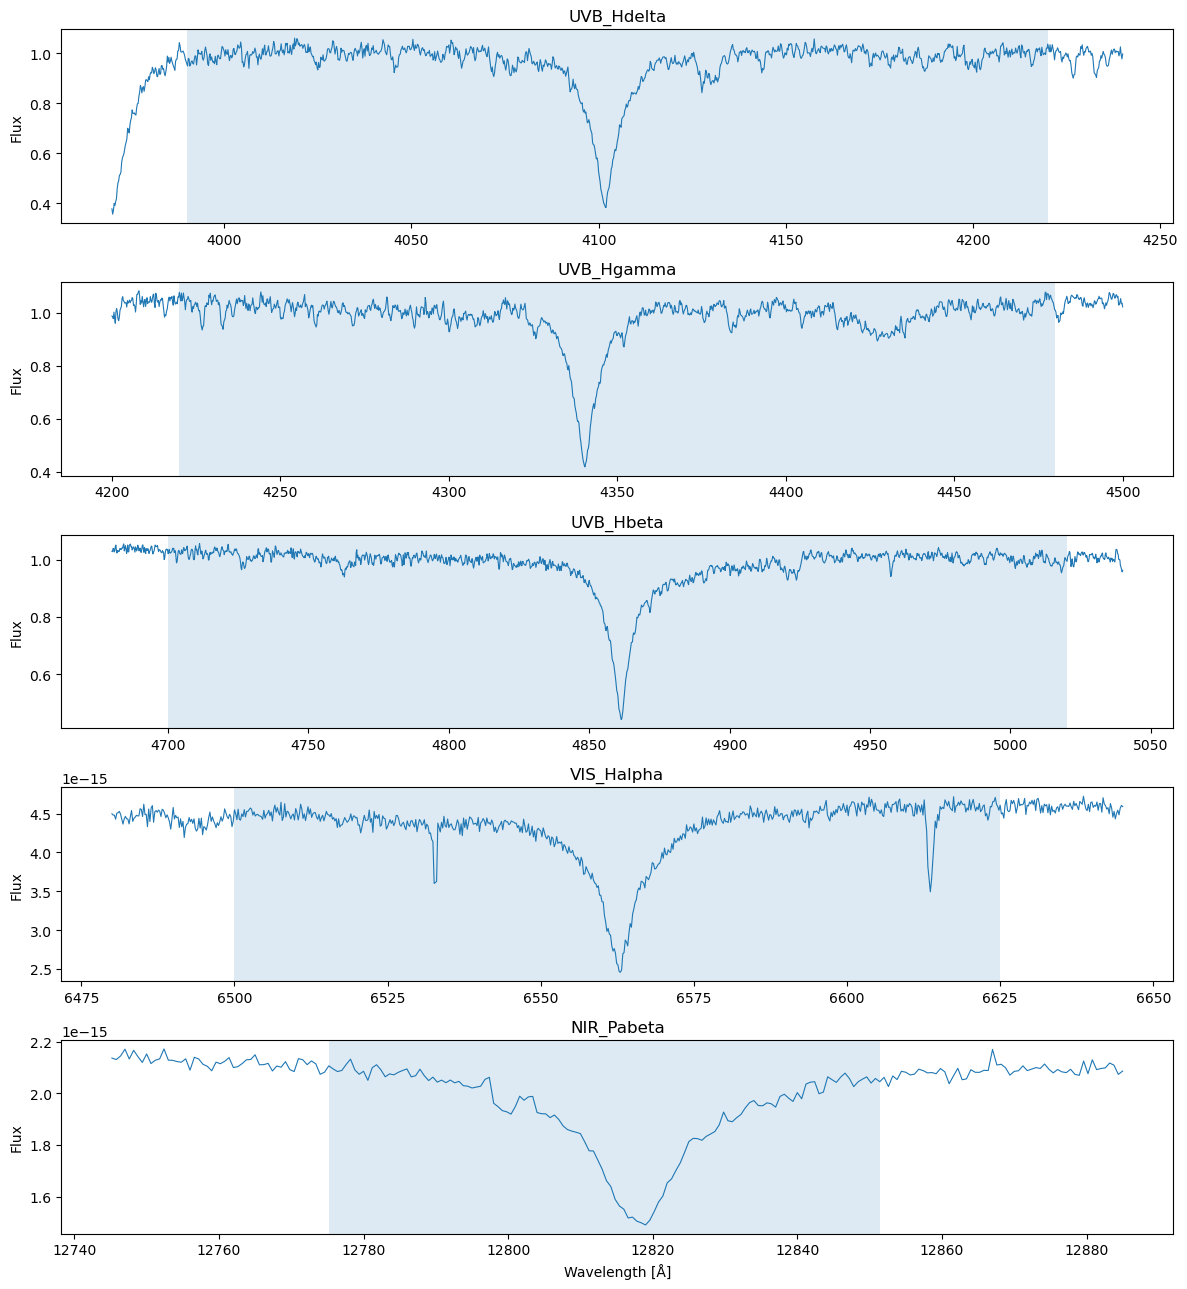

In [7]:
all_segments_for_plot = uvb_segments + vis_segments + nir_segments

nseg = len(all_segments_for_plot)
fig, axes = plt.subplots(nseg, 1, figsize=(12, 2.6 * nseg), sharex=False)

if nseg == 1:
    axes = [axes]

for ax, seg in zip(axes, all_segments_for_plot):
    ax.plot(seg.wave, seg.flux, lw=0.8)
    fit_mask = np.asarray(seg.mask, dtype=bool)
    if np.any(fit_mask):
        ax.axvspan(seg.wave[fit_mask].min(), seg.wave[fit_mask].max(), alpha=0.15)
    ax.set_title(seg.name)
    ax.set_ylabel("Flux")

axes[-1].set_xlabel("Wavelength [Å]")
plt.tight_layout()
plt.show()


## 8. Build the `SpectrumCollection` objects

We compare three cases:
- UVB only
- UVB + VIS
- UVB + VIS + NIR

By default, we balance the total weight of each arm so one arm does not dominate simply because it contributes more windows.


This notebook sideband-normalizes the UVB Balmer windows before fitting, while the simpler UVB notebook fits the original flux with a per-window polynomial continuum. The two examples therefore test related but not identical workflows. Agreement at the broad classification level is more important than exact equality of the fitted parameters.

In [8]:
def make_arm_balanced_weights(*segment_groups):
    weights = []
    for group in segment_groups:
        if len(group) == 0:
            continue
        w = 1.0 / float(len(group))
        weights.extend([w] * len(group))
    return np.asarray(weights, dtype=float)

uvb_only_segments = list(uvb_segments)
uvb_vis_segments = list(uvb_segments) + list(vis_segments)
uvb_vis_nir_segments = list(uvb_segments) + list(vis_segments) + list(nir_segments)

# 1. UVB-only is the baseline classification.
uvb_only = SpectrumCollection(
    uvb_only_segments,
    weights=make_arm_balanced_weights(uvb_segments),
    name="UVB only",
)

# 2. UVB + Halpha is a consistency check.
uvb_vis = SpectrumCollection(
    uvb_vis_segments,
    weights=make_arm_balanced_weights(uvb_segments, vis_segments),
    name="UVB + VIS",
)

# 3. UVB + Halpha + Pabeta is exploratory.
uvb_vis_nir = SpectrumCollection(
    uvb_vis_nir_segments,
    weights=make_arm_balanced_weights(uvb_segments, vis_segments, nir_segments),
    name="UVB + VIS + NIR",
)

for coll in [uvb_only, uvb_vis, uvb_vis_nir]:
    print(coll.name)
    print("  n_segments:", len(coll))
    print("  weights   :", coll.weights.tolist())
    print("  names     :", coll.names)


UVB only
  n_segments: 3
  weights   : [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
  names     : ['UVB_Hdelta', 'UVB_Hgamma', 'UVB_Hbeta']
UVB + VIS
  n_segments: 4
  weights   : [0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 1.0]
  names     : ['UVB_Hdelta', 'UVB_Hgamma', 'UVB_Hbeta', 'VIS_Halpha']
UVB + VIS + NIR
  n_segments: 5
  weights   : [0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 1.0, 1.0]
  names     : ['UVB_Hdelta', 'UVB_Hgamma', 'UVB_Hbeta', 'VIS_Halpha', 'NIR_Pabeta']


## 9. Inspect the segment-specific broadening metadata

The fitter can now use segment-specific line-spread information from the segment metadata.

Before fitting, it is useful to confirm what each selected segment carries. In this example, the X-SHOOTER reader provides a nominal resolving power `resolution_R` for each arm. We let the fitter use those per-segment values directly, rather than forcing one common value across all windows.


In [9]:
all_selected_segments = uvb_vis_nir_segments

for seg in all_selected_segments:
    print(
        seg.name,
        "resolution_R =", seg.meta.get("resolution_R"),
        "fwhm_kms =", seg.meta.get("fwhm_kms"),
        "lsf_fwhm_kms =", seg.meta.get("lsf_fwhm_kms"),
    )

phoenix_lib = PhoenixLibrary(phoenix_dir, verbose=False)


UVB_Hdelta resolution_R = 5400.0 fwhm_kms = None lsf_fwhm_kms = None
UVB_Hgamma resolution_R = 5400.0 fwhm_kms = None lsf_fwhm_kms = None
UVB_Hbeta resolution_R = 5400.0 fwhm_kms = None lsf_fwhm_kms = None
VIS_Halpha resolution_R = 11000.0 fwhm_kms = None lsf_fwhm_kms = None
NIR_Pabeta resolution_R = 8100.0 fwhm_kms = None lsf_fwhm_kms = None


## 10. Define a small fit helper

To keep the notebook readable, we wrap the main fitter call in a short helper function.

Here we pass only the settings that matter most for this example. In particular, we do **not** force a single global resolving power. The fitter now reads the segment-specific broadening information directly from the segment metadata.


In [10]:
teff_grid = np.array([9600., 9800., 10000., 10200., 10400., 10600., 10800., 11000., 11200., 11400., 11600., 11800.])
feh_grid = np.array([-0.5, 0.0, 0.5])
logg_grid = np.array([3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0])

p0 = (9800.0, -0.5, 3.0, -5.0)

def run_collection_fit(collection, exclude_mask=None, label=None):
    result = fit_phoenix_full_spectrum(
        segments=collection,
        phoenix_lib=phoenix_lib,
        p0=p0,
        exclude_mask=exclude_mask,
        mdeg=1,
        forward_model="native_interp",
        teff_grid=teff_grid,
        feh_grid=feh_grid,
        logg_grid=logg_grid,
        rv_init="grid",
        verbose=0,
        max_nfev=200,
    )
    if label is not None:
        result["label"] = label
    return result


## 11. Run the fits

We first fit the UVB-only collection, then add the VIS window, and finally add the NIR windows.


In [11]:
results = []

results.append(run_collection_fit(uvb_only, exclude_mask=uvb_exclude_mask, label="UVB only"))
results.append(run_collection_fit(uvb_vis, exclude_mask=uvb_exclude_mask, label="UVB + VIS"))
results.append(run_collection_fit(uvb_vis_nir, exclude_mask=uvb_exclude_mask, label="UVB + VIS + NIR"))

fit_rows = []
for res in results:
    fit_rows.append(
        {
            "label": res["label"],
            "teff": res["teff"],
            "feh": res["feh"],
            "logg": res["logg"],
            "rv_kms": res["rv_kms"],
            "chi2_red": res["chi2_red"],
            "n_segments": res["n_segments"],
            "success": res["success"],
        }
    )

print_table(
    fit_rows,
    columns=["label", "teff", "feh", "logg", "rv_kms", "chi2_red", "n_segments", "success"],
    float_formats={
        "teff": ".1f",
        "feh": ".3f",
        "logg": ".3f",
        "rv_kms": ".2f",
        "chi2_red": ".3f",
    },
)

for row in fit_rows:
    if abs(row["teff"] - teff_grid.max()) < 1.0:
        print(f"WARNING: {row['label']} is at the upper Teff grid edge.")
    if abs(row["feh"] - feh_grid.min()) < 1e-3 or abs(row["feh"] - feh_grid.max()) < 1e-3:
        print(f"WARNING: {row['label']} is at a metallicity grid edge.")

label           | teff    | feh    | logg  | rv_kms | chi2_red | n_segments | success
----------------+---------+--------+-------+--------+----------+------------+--------
UVB only        | 10801.6 | -0.435 | 3.066 | -10.57 | 2.265    | 3          | True   
UVB + VIS       | 11779.0 | -0.497 | 3.184 | -3.05  | 2.765    | 4          | True   
UVB + VIS + NIR | 11767.7 | -0.500 | 3.201 | -1.08  | 2.912    | 5          | True   


## 12. Inspect the per-segment models

Here we reconstruct the model on each segment and compare it directly to the data.


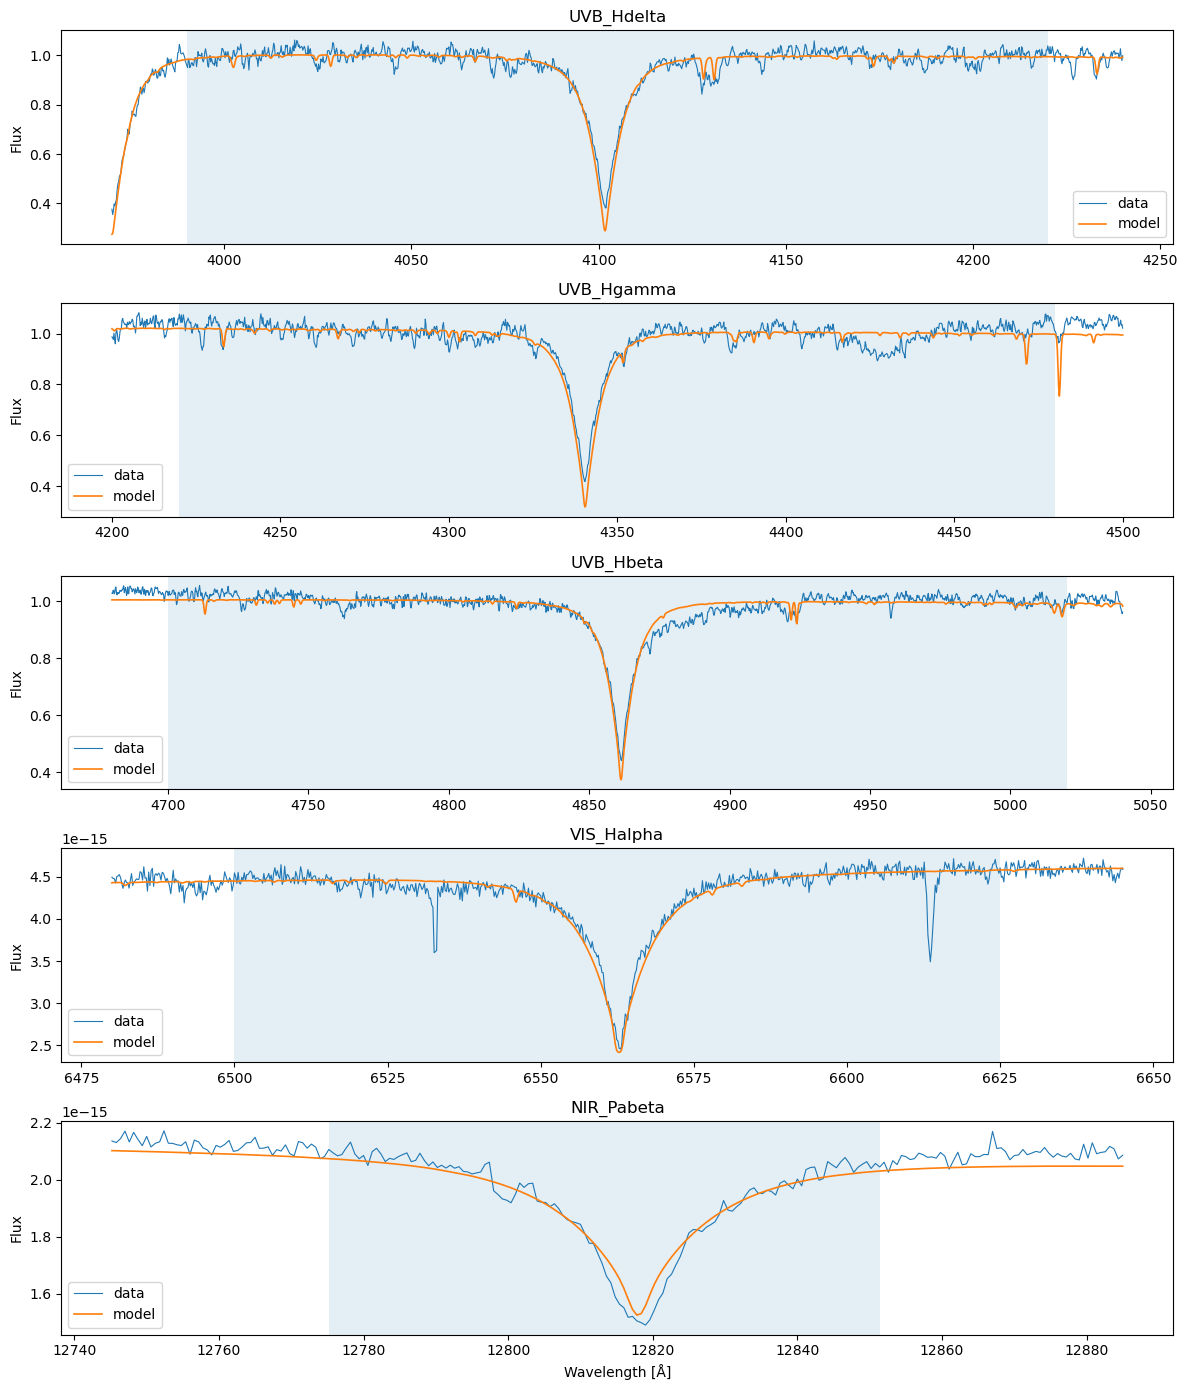

In [12]:
best_result = results[-1]
best_collection = uvb_vis_nir

model_full_list, coeffs_list, used_masks, excluded_masks = reconstruct_phoenix_legendre_models_for_segments(
    best_collection,
    phoenix_lib=phoenix_lib,
    fit_result=best_result,
    exclude_mask=uvb_exclude_mask,
    mdeg=1,
    forward_model="native_interp",
)

nseg = len(best_collection)
fig, axes = plt.subplots(nseg, 1, figsize=(12, 2.8 * nseg), sharex=False)

if nseg == 1:
    axes = [axes]

for ax, seg, model_full, used_mask in zip(axes, best_collection, model_full_list, used_masks):
    ax.plot(seg.wave, seg.flux, lw=0.8, label="data")
    ax.plot(seg.wave, model_full, lw=1.2, label="model")
    if np.any(used_mask):
        ax.axvspan(seg.wave[used_mask].min(), seg.wave[used_mask].max(), alpha=0.12)
    ax.set_title(seg.name)
    ax.set_ylabel("Flux")
    ax.legend(loc="best")

axes[-1].set_xlabel("Wavelength [Å]")
plt.tight_layout()
plt.show()


## 13. Print a compact summary

This gives a short text summary that is easy to copy into notes.


In [13]:
for res in results:
    print("=" * 72)
    print(res["label"])
    print("  Teff      =", res["teff"])
    print("  [Fe/H]    =", res["feh"])
    print("  logg      =", res["logg"])
    print("  RV [km/s] =", res["rv_kms"])
    print("  chi2_red  =", res["chi2_red"])
    print("  n_segments=", res["n_segments"])
    print("  names     =", res["segment_names"])
    print("  weights   =", res["segment_weights"])


UVB only
  Teff      = 10801.563201130215
  [Fe/H]    = -0.4346978238435111
  logg      = 3.0662900962500554
  RV [km/s] = -10.571000720249149
  chi2_red  = 2.2646471441152567
  n_segments= 3
  names     = ['UVB_Hdelta', 'UVB_Hgamma', 'UVB_Hbeta']
  weights   = [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
UVB + VIS
  Teff      = 11778.9517756092
  [Fe/H]    = -0.49738260477028706
  logg      = 3.18393330893306
  RV [km/s] = -3.047971441136603
  chi2_red  = 2.764991823807381
  n_segments= 4
  names     = ['UVB_Hdelta', 'UVB_Hgamma', 'UVB_Hbeta', 'VIS_Halpha']
  weights   = [0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 1.0]
UVB + VIS + NIR
  Teff      = 11767.683610173082
  [Fe/H]    = -0.4999999997235279
  logg      = 3.2009622329843683
  RV [km/s] = -1.0781207187215807
  chi2_red  = 2.912431747230757
  n_segments= 5
  names     = ['UVB_Hdelta', 'UVB_Hgamma', 'UVB_Hbeta', 'VIS_Halpha', 'NIR_Pabeta']
  weights   = [0.3333333333333333, 0.3333333333333333, 0.

## 14. Interpretation and caveats

This notebook is an advanced worked example, not a final precision-analysis template.

A few points to keep in mind:

- the fitter now uses the segment-specific broadening metadata carried by each selected segment
- the VIS and NIR products here are telluric-corrected, but residuals can still matter
- the selected VIS and NIR windows are first-pass choices and can be edited
- different arms do not always constrain the model in the same way, so it is important to inspect the per-segment residuals and compare how the inferred parameters change when new windows are added

Why can the UVB-only and multi-arm results differ?

The UVB fit is driven mainly by the broad Balmer lines Hdelta, Hgamma, and Hbeta. These are usually the cleanest and most informative diagnostics in this example, especially in their wings. When VIS and NIR windows are added, the fit also tries to match Halpha and the selected near-infrared hydrogen lines. Those extra windows can add useful information, but they can also introduce extra sensitivity to continuum placement, telluric residuals, wavelength-convention choices, and the local broadening assumptions.

A fit that uses more windows is therefore not automatically more reliable. It is solving a broader problem, under more assumptions.

Which result should you trust more?

For a case like this, the UVB-only fit is a sensible baseline because it is driven by the Balmer wings that carry most of the temperature and gravity information. The mixed-arm fit should be treated as a consistency test unless the added VIS and NIR windows improve the fit in a stable and physically sensible way.

In practice, a good workflow is:

1. fit the UVB windows alone and inspect the residuals
2. add the VIS window and see how much the solution shifts
3. add the NIR windows and compare again
4. check whether the added windows improve the fit without introducing obvious new systematic mismatches

What should you look for?

Small changes in the fitted parameters are reassuring. Large shifts are a sign to look more carefully at the assumptions. In particular, it is worth checking:

- whether the result is stable if you adjust the window boundaries slightly
- whether the answer changes when you widen or narrow the masked line cores
- whether one arm still shows structured residuals after the fit
- whether the inferred solution depends strongly on the chosen segment weights
- whether the broadening and wavelength conventions are being handled consistently across arms

If the parameters change only slightly and the residuals improve across the added segments, the multi-arm result is more persuasive. If the parameters shift strongly or one arm still shows clear systematic residuals, then the UVB-only result is often the cleaner baseline while the mixed-arm setup still needs refinement.

For this example, the UVB Balmer-wing result is the natural reference point. The mixed-arm result is most useful as an exploratory extension of that baseline and as a check on how much additional windows pull the solution.
